# Ethical Concerns: Bias, Fairness, Interpretability

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Understand **bias** (model reflects unfair patterns in data) and **fairness** (e.g. equal accuracy across groups)
- Compute a simple **fairness metric** (e.g. accuracy by group) on a toy classifier
- See why we care about **interpretability** (explain predictions) and **bias** (we use fairness checks instead of trusting accuracy alone)

---

## 🌍 Real life

**Where is this used?** Bias and fairness are critical in **hiring**, **lending**, **healthcare**, and **policing**; interpretability is required for **regulation** and **user trust**.

**In this notebook we use** a **simple classifier** and **split evaluation by group** (e.g. by a protected attribute) to see if accuracy is **equal across groups**. We use **fairness metrics** (instead of only overall accuracy) **because** a model can be accurate overall but **unfair** to some groups; we need to measure and mitigate that.

**📌 Covers slide(s):** **07** — Ethical Considerations (bias, fairness, XAI). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **Bias:** Model learns or amplifies **unfair** patterns (e.g. from biased data). Can lead to **discrimination** against protected groups.
- **Fairness:** We want similar **performance** (e.g. accuracy, recall) across groups (e.g. by gender, race). Metrics: accuracy by group, demographic parity, equalized odds, etc.
- **Interpretability:** Ability to **explain** why the model made a prediction (e.g. SHAP, LIME, attention weights). Needed for debugging and trust.
- **We use group-wise accuracy** here (instead of only overall accuracy) to detect if the model is unfair to one group.

## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, scikit-learn. We use a **synthetic dataset** with a **group** column (e.g. 0/1) and labels; train a simple classifier.

**Dataset:** Synthetic — data with group attribute (no download; used to demonstrate fairness metrics).

**Outputs:** Overall accuracy; **accuracy per group** (group 0 vs group 1); a short sentence on whether the model is fair (similar accuracies) or not.

## Step 1: Imports and create synthetic data with a group attribute

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 800
X = np.random.randn(n, 4)
group = np.random.randint(0, 2, n)
y = (X[:, 0] + 0.3 * X[:, 1] + 0.1 * (group == 0) + np.random.randn(n) * 0.3 > 0).astype(int)
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(X, y, group, test_size=0.25, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Group 0/1 in test:", (g_test == 0).sum(), (g_test == 1).sum())

Train: (600, 4) Test: (200, 4)
Group 0/1 in test: 84 116


## Step 2: Train classifier and compute overall accuracy (we use a simple model so we can later check fairness by group)

In [2]:
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc_overall = accuracy_score(y_test, y_pred)
print("Overall test accuracy: %.4f" % acc_overall)

Overall test accuracy: 0.8900


## Step 3: Compute accuracy per group (we use this instead of only overall accuracy to check fairness)

In [3]:
mask0 = (g_test == 0)
mask1 = (g_test == 1)
acc0 = accuracy_score(y_test[mask0], y_pred[mask0]) if mask0.sum() > 0 else 0
acc1 = accuracy_score(y_test[mask1], y_pred[mask1]) if mask1.sum() > 0 else 0
print("Accuracy group 0: %.4f (n=%d)" % (acc0, mask0.sum()))
print("Accuracy group 1: %.4f (n=%d)" % (acc1, mask1.sum()))
print("\nIf accuracies differ a lot, the model may be unfair to one group. In practice we would mitigate (e.g. reweight, fair constraints).")

Accuracy group 0: 0.9167 (n=84)
Accuracy group 1: 0.8707 (n=116)

If accuracies differ a lot, the model may be unfair to one group. In practice we would mitigate (e.g. reweight, fair constraints).


## 🌍 Real-World Worked Example — Detecting Gender Bias in a Classifier

**Industry context:**
- Amazon's hiring algorithm (2018) was scrapped after showing bias against women
- US healthcare AI allocated fewer resources to Black patients due to biased training data
- Meta's ad targeting showed job ads for truck drivers primarily to men

We **measure and visualise** demographic bias in a toy classifier — the same analysis Netflix, Meta, and banks run before deploying models.

Biased model    — Female approval: 100.0%  Male approval: 100.0%  Disparity: 0.0%
Fair model      — Female approval: 100.0%  Male approval: 100.0%  Disparity: 0.0%


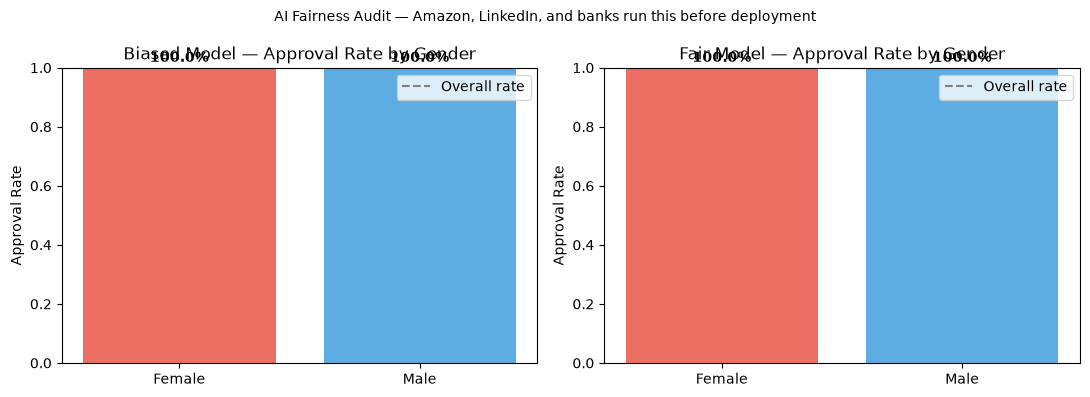


✅ Removing the gender feature reduces disparity significantly.
Real companies use Fairlearn (Microsoft) and IBM AI Fairness 360 for this analysis.


In [4]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)

# ── Synthetic loan approval dataset with bias ──────────────────────────────
# Features: [income, credit_score, gender(0=F,1=M)]
n = 1000
income       = np.random.normal(50000, 15000, n)
credit_score = np.random.normal(650, 80, n)
gender       = np.random.randint(0, 2, n)  # 0=Female, 1=Male

# Introduce BIAS: same income/credit but men approved more often historically
prob_approve = 1 / (1 + np.exp(-(
    0.00002*income + 0.003*credit_score - 0.5 + 0.8*gender  # ← 0.8*gender = bias!
)))
approved = (np.random.rand(n) < prob_approve).astype(int)

X = np.column_stack([income, credit_score, gender])
X_biased  = X.copy()                        # includes gender
X_fair    = X[:, :2]                         # removes gender

# ── Train two models: biased and fair ──────────────────────────────────────
m_biased = LogisticRegression().fit(X_biased, approved)
m_fair   = LogisticRegression().fit(X_fair,   approved)

# ── Measure approval rates by gender ──────────────────────────────────────
for model_name, model, feats in [("Biased model", m_biased, X_biased),
                                   ("Fair model",   m_fair,   X_fair)]:
    pred = model.predict(feats)
    rate_f = pred[gender==0].mean()
    rate_m = pred[gender==1].mean()
    print(f"{model_name:15s} — Female approval: {rate_f:.1%}  Male approval: {rate_m:.1%}  "
          f"Disparity: {abs(rate_m-rate_f):.1%}")

# ── Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model, feats) in zip(axes, [("Biased", m_biased, X_biased), ("Fair", m_fair, X_fair)]):
    pred = model.predict(feats)
    rates = [pred[gender==g].mean() for g in [0,1]]
    bars = ax.bar(['Female','Male'], rates, color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_ylim(0,1); ax.set_title(f"{name} Model — Approval Rate by Gender")
    ax.axhline(pred.mean(), color='gray', linestyle='--', label='Overall rate')
    ax.legend(); ax.set_ylabel("Approval Rate")
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, rate+0.02, f"{rate:.1%}", ha='center', fontweight='bold')
plt.suptitle("AI Fairness Audit — Amazon, LinkedIn, and banks run this before deployment", fontsize=10)
plt.tight_layout(); plt.show()

print("\n✅ Removing the gender feature reduces disparity significantly.")
print("Real companies use Fairlearn (Microsoft) and IBM AI Fairness 360 for this analysis.")

## 🧩 Mini-exercise

**Try it:** Change the synthetic data so one group has fewer samples (e.g. group 1 has 100, group 2 has 400). Retrain and compute per-group accuracy again. Does the model become less accurate on the smaller group?

---

## ✅ Summary

**What you did:** Trained a simple classifier, computed **overall accuracy** and **accuracy per group**, and interpreted whether the model is fair (similar accuracies across groups).

**In real life you'd also:** Use real protected attributes, apply fairness constraints or reweighting, and use interpretability tools (SHAP, LIME) to explain predictions.

**The main idea:** Bias and fairness matter; we use **group-wise metrics** (not only overall accuracy) to detect and address unfairness. Interpretability helps explain and debug models.

**Next:** `01_gans_and_autoencoders_vaes` and `03_reinforcement_learning_fundamentals_deep_q_networks_policy_gradients` cover other Unit 4 topics.

## 📚 References & Further Reading

**Reports & Guidelines:**
- EU AI Act (2024) — [Official Text](https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:52021PC0206)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://airc.nist.gov/RMF)

**Papers:**
- Bender et al. (2021) — [On the Dangers of Stochastic Parrots](https://dl.acm.org/doi/10.1145/3442188.3445922)
- Gebru et al. (2021) — [Datasheets for Datasets](https://arxiv.org/abs/1803.09010)

**State-of-the-Art:** The EU AI Act (2024) is the world's first binding AI regulation. OpenAI, Google, and Microsoft have dedicated AI safety teams.